In [1]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

c:\Users\jbred\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 103/103 [00:00<00:00, 394.50it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [4]:
sentences = [
    # Cricket
    "The batsman hit a six on the last ball of the over",
    "India won the match by 5 wickets in the final over",
    "The spinner bowled a brilliant googly to dismiss the opener",

    # Cooking
    "Add salt and pepper to the pan before frying the vegetables",
    "Preheat the oven to 180 degrees before baking the cake",
    "Marinate the chicken in yogurt and spices for two hours",
    "Stir the curry continuously to prevent it from burning",

    # Cybersecurity
    "The hacker used a phishing email to steal login credentials",
    "Always enable two-factor authentication to protect your accounts",
    "A firewall monitors incoming and outgoing network traffic for threats",
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


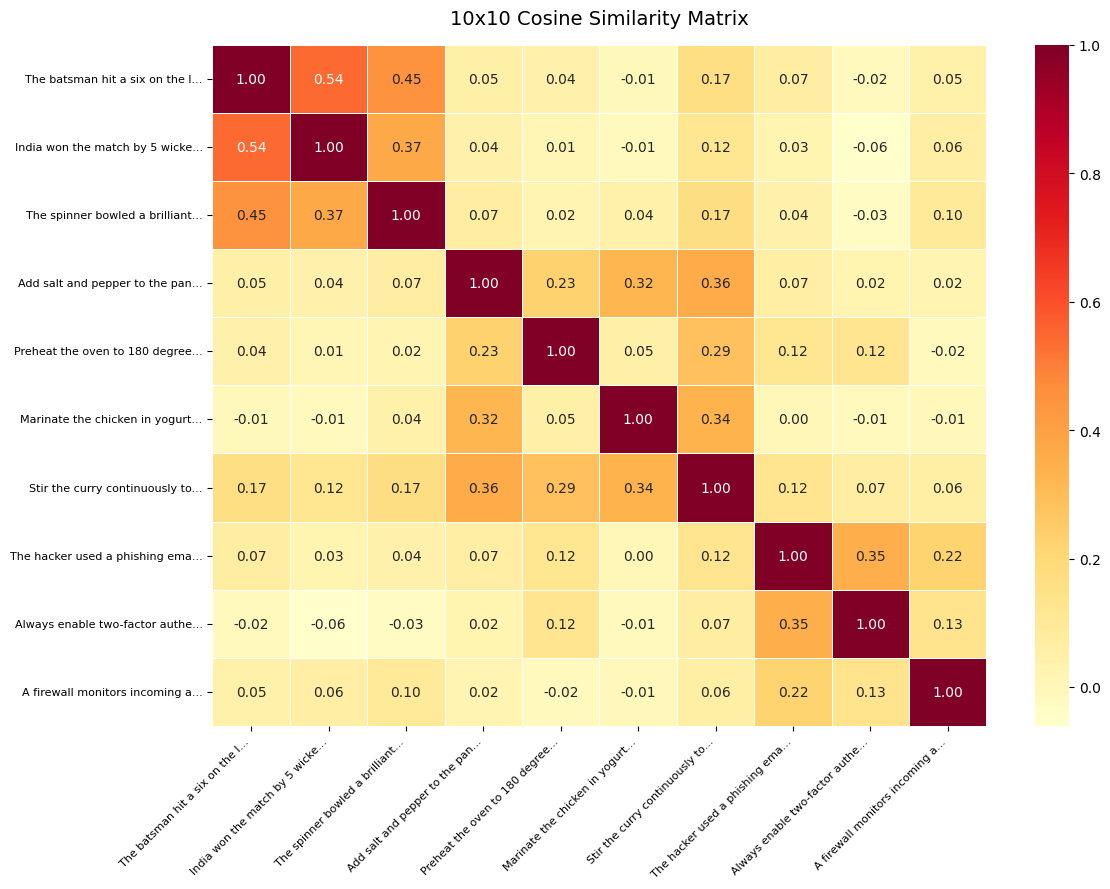

In [5]:
embeddings = model.encode(sentences)

# Compute 10x10 cosine similarity matrix
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

# Plot heatmap
plt.figure(figsize=(12, 9))
short_labels = [s[:30] + "..." for s in sentences]
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=short_labels,
    yticklabels=short_labels,
    linewidths=0.5
)
plt.title("10x10 Cosine Similarity Matrix", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

scores = util.cos_sim(query_embedding, embeddings)[0]

# Get top 2
top2 = np.argsort(scores.numpy())[::-1][:2]

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:")
for rank, idx in enumerate(top2, 1):
    print(f"  {rank}. \"{sentences[idx]}\"")
    print(f"     Similarity Score: {scores[idx]:.4f}\n")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
  1. "India won the match by 5 wickets in the final over"
     Similarity Score: 0.6785

  2. "The batsman hit a six on the last ball of the over"
     Similarity Score: 0.6223

